In [1]:
import casadi as ca
import numpy as np
import time
from corti.bezier_rover_planning import generate_path
from corti.rover_planning import RoverPlanner

In [2]:
def shift_timestep(h, state, control, f):
    delta_state = f(state, control[:, 0], p)
    next_state = ca.DM.full(state + h * delta_state)
    next_control = ca.horzcat(control[:, 1:],
                                  ca.reshape(control[:, -1], -1, 1))

    return next_state, next_control
def dm_to_array(dm):
    return np.array(dm.full())

In [3]:
## single shooting method
# x0 is known
# know x1_p = f(x0, u0)
#
# find optimal u0 such that
# x1 = xt  (for simple case xt = x0)

## multiple shooting method
# x0 is known
# know x1_p = f(x0, u0)
#
# find optimal u0 such that
# x1 = xt  (for simple case xt = x0)

def nlp_multiple_shooting(eqs, N, dt):
    f = eqs['f']
    
    n_x = eqs['x'].numel()  # numbef of states
    n_u = eqs['u'].numel()  # number of inputs
    n_p = eqs['p'].numel()
    P = ca.SX.sym('P', n_p+(N+1)*n_x,1)
    p = P[:n_p]
    x0 = P[n_p:n_p+n_x]
    # xt = P[n_p+n_x:]

    Q_x = 1000
    Q_y = 1000
    Q_theta = 1
    Q_vx = 0
    Q_vy = 0
    Q_omega = 0

    R1 = 1
    R2 = 1
    Q = ca.diagcat(Q_x, Q_y, Q_theta, Q_vx, Q_vy, Q_omega)
    R = ca.diagcat(R1, R2)

    t0 = 0

    x_opt = ca.SX.sym('x_opt', n_x, N+1)
    u_opt = ca.SX.sym('u_opt', n_u, N)
    
    # design vector for optimization
    xd_opt = ca.vertcat(x_opt.reshape((-1, 1)), u_opt.reshape((-1, 1)))
    
    f_cost = 0
    f_constraint = x_opt[:,0] - x0
    
    for k in range(N):
        u0 = u_opt[:,k]
        x = x_opt[:,k]
        xt = P[n_p+(k+1)*n_x:n_p+(k+2)*n_x]
        x_next = x_opt[:,k+1]
        h = ca.SX.sym('h')
        # one step of rk4
        
        k_1 = f(x, u0, p)
        k_2 = f(x + dt/2 * k_1, u0, p)
        k_3 = f(x + dt/2 * k_2, u0, p)
        k_4 = f(x + dt * k_3, u0, p)
        x1 = x + dt/6 * (k_1 + 2 * k_2 + 2 * k_3 + k_4)
        # x1 = ca.substitute(rk4(f=lambda t, x: f(x0, u0, p), t=t0, y=x0, h=h), h, dt)
        
        # cost is how far we are at the end of the simulation from the desired target
        f_cost = f_cost + (x - xt).T @Q@ (x - xt) + u0.T@R@u0
        # print('f_cost', f_cost)
        f_constraint = ca.vertcat(f_constraint, x_next - x1) # how far dynamic simulation is off from rk4
    
    nlp_prob = {
        'f': f_cost,
        'x': xd_opt,
        'g': f_constraint,
        'p': P,
    }
    opts = {
        'ipopt':  {
            'max_iter': 2000,
            'print_level': 0,
            'acceptable_tol': 1e-8,
            'acceptable_obj_change_tol': 1e-6,
        },
        'print_time': 0,
    }
    return locals()

In [4]:
def update_param(x0, ref, k, N):
    p = ca.vertcat(x0)
    for l in range(N):
        if k+l < ref.shape[0]:
            ref_state = ref[k+l, :]
            v = 1
        else:
            ref_state = ref[-1, :]
            v = 0
        xt = ca.DM([ref_state[0], ref_state[1], ref_state[2], ref_state[3], ref_state[4], 0])
        p = ca.vertcat(p, xt)
    return p

In [5]:
def second_sys():
    px = ca.SX.sym('px')
    py = ca.SX.sym('py')
    theta = ca.SX.sym('theta')
    vx = ca.SX.sym('vx')
    vy = ca.SX.sym('vy')
    omega = ca.SX.sym('omega')
    p = ca.SX.sym('p')

    x = ca.vertcat(px, py, theta, vx, vy, omega)

    a = ca.SX.sym('a')
    alpha = ca.SX.sym('alpha')

    u = ca.vertcat(a, alpha)

    RHS = ca.vertcat(
        vx,
        vy,
        omega,
        a*ca.cos(theta),
        a*ca.sin(theta),
        alpha
    )

    f = ca.Function('f', [x, u, p], [RHS])
    return locals()

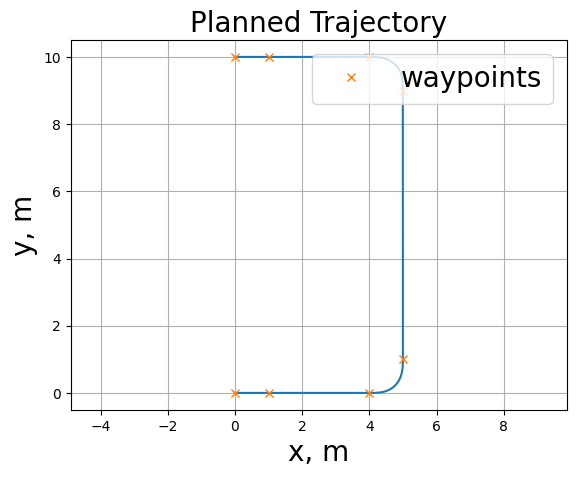

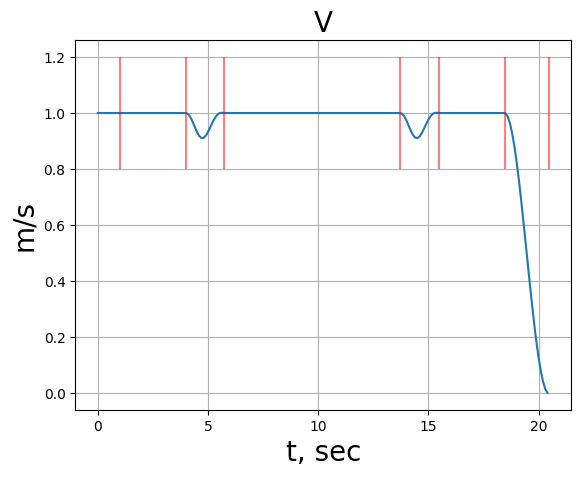

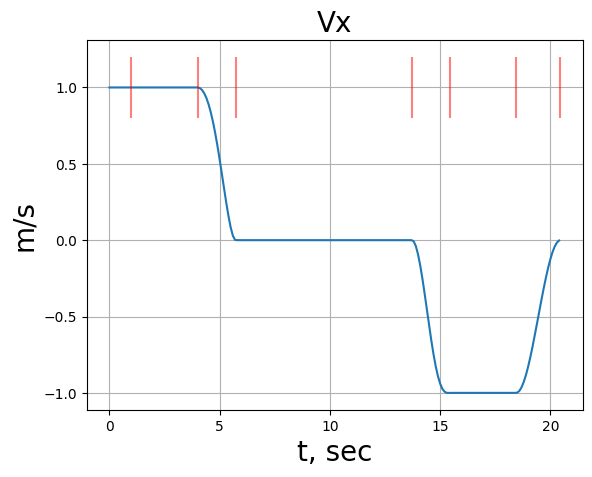

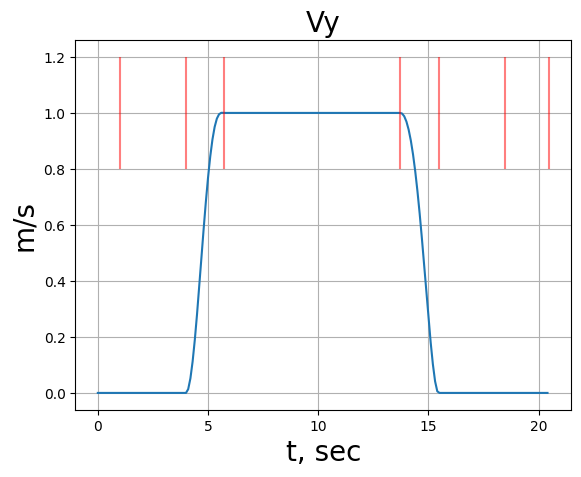

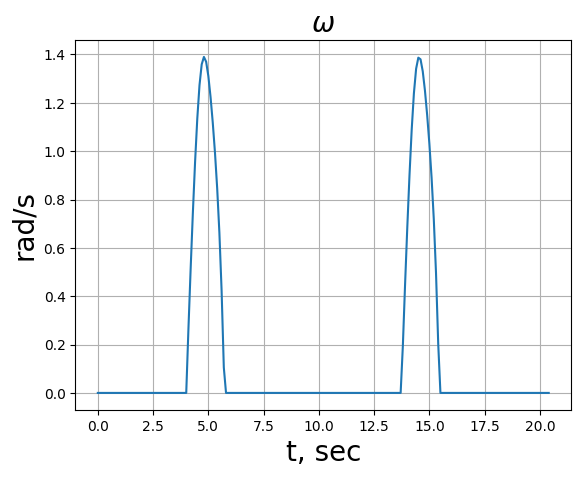

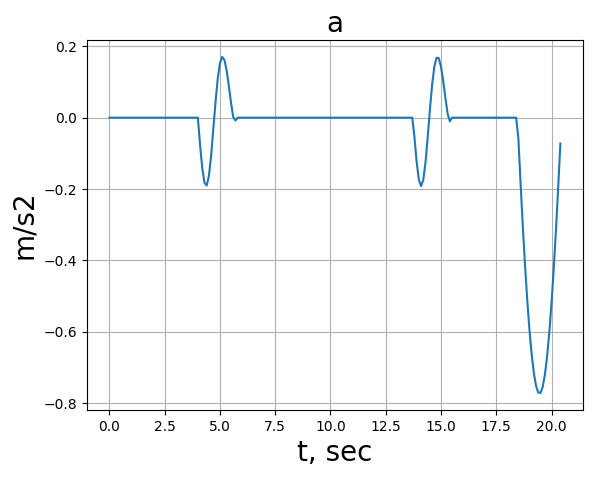

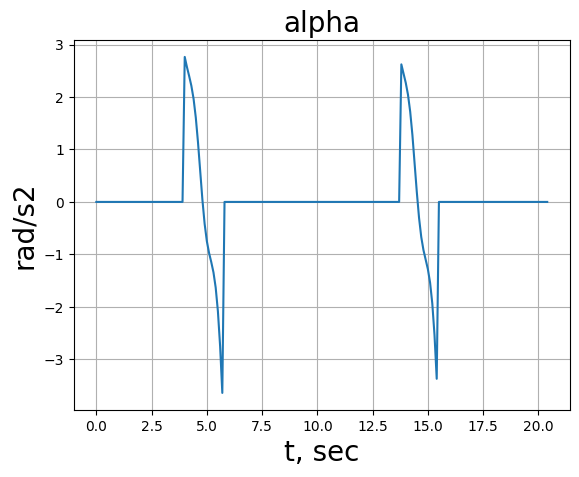

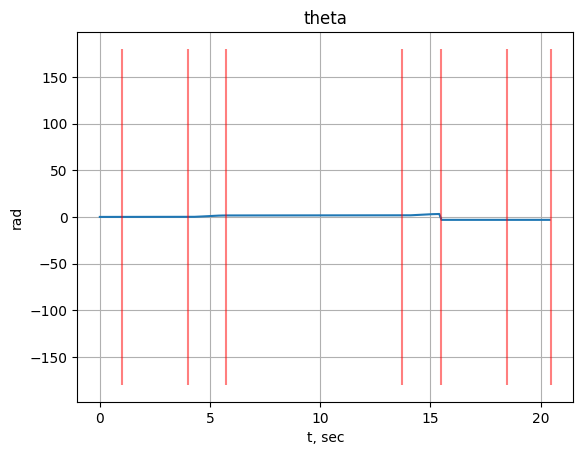

In [6]:
v  = 1
r = 1
planner = RoverPlanner(x=0, y=0, v=v, theta=0, r=r)
planner.goto(5, 0, v, r)
planner.goto(5, 10, v, r)
planner.goto(0, 10, v, r)
# planner.goto(0, 0, v, r)
# planner.goto(-3, 0, v, r)
# planner.goto(-3, 3, v, r)
# planner.goto(0, 3, v, r)
# planner.goto(0, 6, v, r)
# planner.goto(3, 6, v, r)
# planner.goto(3, 3, v, r)
# planner.goto(-3, 3, v, r)
# planner.goto(-3, 6, v, r)
planner.stop(0, 10)

ref_data = planner.compute_ref_data(plot=True)
t = ref_data['t']
xt = np.array([ref_data['x'](t), ref_data['y'](t), ref_data['theta'](t), ref_data['vx'](t), ref_data['vy'](t)]).T

In [12]:
second = second_sys()

N = 100
dt = 0.1
nlp = nlp_multiple_shooting(second,N,dt)
solver = ca.nlpsol('solver', 'ipopt', nlp['nlp_prob'], nlp['opts'])

n_x = nlp['n_x']
n_u = nlp['n_u']

a_max =  0.3
a_min = -0.3

alpha_max = 1 # Torque
alpha_min = -1

vx_min = -1
vy_min = -1
vx_max = 1
vy_max = 1

omega_min = -3
omega_max = 3

lbg = ca.DM.zeros((n_x * (N+1)))
ubg = -ca.DM.zeros((n_x * (N+1)))

lbx = ca.DM.zeros((n_x * (N + 1) + n_u * N, 1))
ubx = ca.DM.zeros((n_x * (N + 1) + n_u * N, 1))

lbx[0: n_x*(N + 1): n_x] = -ca.inf     # X lower bound
lbx[1: n_x*(N + 1): n_x] = -ca.inf     # Y lower bound
lbx[2: n_x*(N + 1): n_x] = -ca.pi   # theta lower bound
lbx[3: n_x*(N + 1): n_x] = vx_min       # VX lower bound
lbx[4: n_x*(N + 1): n_x] = vy_min       # VY lower bound
lbx[5: n_x*(N + 1): n_x] = omega_min   # omega lower bound

ubx[0: n_x*(N + 1): n_x] = ca.inf      # X upper bound
ubx[1: n_x*(N + 1): n_x] = ca.inf      # Y upper bound
ubx[2: n_x*(N + 1): n_x] = ca.pi     # theta upper bound
ubx[3: n_x*(N + 1): n_x] = vx_max       # VX upper bound
ubx[4: n_x*(N + 1): n_x] = vy_max       # VY upper bound
ubx[5: n_x*(N + 1): n_x] = omega_max   # omega upper bound

lbx[n_x*(N + 1)::n_u] = a_min        # force lower bound
lbx[n_x*(N + 1)+1::n_u] = alpha_min    # tau lower bound 

ubx[n_x*(N + 1)::n_u] = a_max        # force upper bound
ubx[n_x*(N + 1)+1::n_u] = alpha_max    # tau upper bound 

args = {
    'lbg': lbg,
    'ubg': ubg,
    'lbx': lbx,
    'ubx': ubx,
}

In [13]:
u0 = ca.DM.zeros(n_u, N)
x0 = ca.DM.zeros(n_x, 1)

p = ca.vertcat(0)

mpc_iter = 0

X0 = ca.repmat(x0, 1, (N + 1))
cat_states = np.array(X0.full())
cat_controls = np.array(u0[:, 0])
times = np.array([[0]])

for i in range(xt.shape[0]):
    t1 = time.time()
    args['P'] = ca.vertcat(p, update_param(x0, xt, i, N))
    # print(args['P'])

    args['x0'] = ca.vertcat(ca.reshape(X0, n_x * (N + 1), 1),
                            ca.reshape(u0, n_u * N, 1))

    sol = solver(x0=args['x0'], lbx=args['lbx'], ubx=args['ubx'],
                 lbg=args['lbg'], ubg=args['ubg'], p=args['P'])
    u = ca.reshape(sol['x'][n_x * (N + 1):], n_u, N)
    # print('control',u[:,0])
    X = ca.reshape(sol['x'][:n_x * (N + 1)], n_x, (N + 1))
    cat_states = np.dstack((cat_states, np.array(X0.full())))
    cat_controls = np.dstack((cat_controls, np.array(u[:, 0])))
    u0 = ca.horzcat(u[:, 1:], ca.reshape(u[:, -1], -1, 1))
    x0, u0 = shift_timestep(dt, x0, u, second['f'])
    X0 = ca.horzcat(X[:, 1:],ca.reshape(X[:, -1], -1, 1))
    # print('states',x0, X0[:,0])
    t2 = time.time()

    times = np.vstack((times, t2 - t1))
    mpc_iter += 1

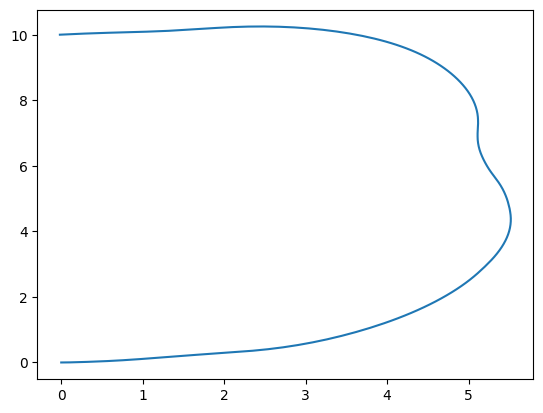

In [16]:
import matplotlib.pyplot as plt
plt.plot(cat_states[0,0,:], cat_states[1,0,:])
# plt.plot(cat_states[1,0,:])
# plt.plot(cat_states[2,0,:])
# plt.plot(cat_states[3,0,:])
# plt.plot(cat_states[4,0,:])
# plt.plot(cat_states[5,0,:])

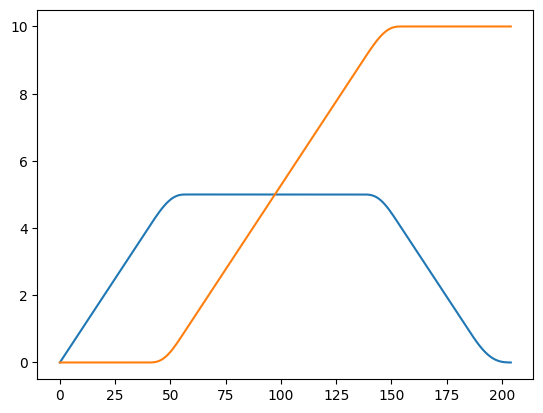

In [15]:
plt.plot(xt[:,0])
plt.plot(xt[:,1])
# plt.plot(xt[:,2])